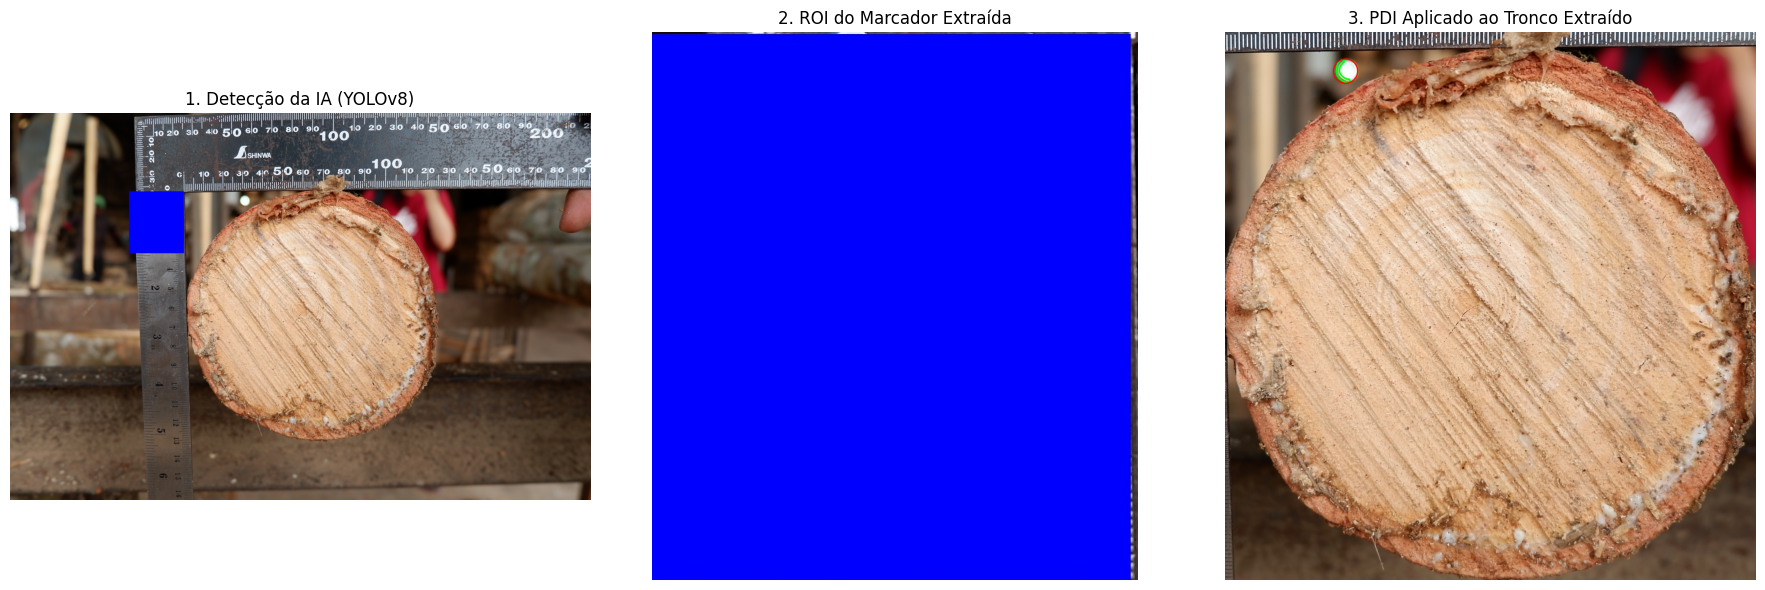

In [1]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

# 1. Carregar o modelo treinado
caminho_modelo = "../runs/detect/medicao_madeira_v2_fast/weights/best.pt"
model = YOLO(caminho_modelo)

# 2. Pegar uma imagem de teste
caminho_imagens = glob.glob("../data/raw/train/images/*.jpg")
img_path = caminho_imagens[0]
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# =========================================================
# PASSO 1: INFERÊNCIA COM YOLOv8 (A Visão Macro)
# =========================================================
resultados = model(img_path, verbose=False)

crop_tronco = None
crop_medida = None

# Extrair as coordenadas das Bounding Boxes detectadas
for box in resultados[0].boxes:
    cls_id = int(box.cls[0])
    # Pega as coordenadas x1, y1 (topo-esquerda) e x2, y2 (baixo-direita)
    x1, y1, x2, y2 = map(int, box.xyxy[0]) 
    
    if cls_id == 0:  # Classe 0 = Crossesction (Madeira)
        crop_tronco = img_bgr[y1:y2, x1:x2]
    elif cls_id == 1: # Classe 1 = Measure (Marcador Azul)
        crop_medida = img_bgr[y1:y2, x1:x2]

if crop_tronco is None or crop_medida is None:
    print("O modelo não encontrou os dois objetos nesta imagem. Tente outra.")
else:
    # =========================================================
    # PASSO 2: AS 5 TÉCNICAS DE PDI (No tronco recortado pela IA)
    # =========================================================
    
    # 1. Escala de Cinza
    gray = cv2.cvtColor(crop_tronco, cv2.COLOR_BGR2GRAY)

    # 2. Suavização Gaussiana (Forte para ignorar anéis da madeira)
    blur = cv2.GaussianBlur(gray, (25, 25), 0)

    # 3. Detecção de Bordas (Canny)
    edges = cv2.Canny(blur, 80, 150)

    # 4. Morfologia Matemática (Dilatação para fechar a borda)
    kernel = np.ones((11,11), np.uint8)
    edges_closed = cv2.dilate(edges, kernel, iterations=1)

    # 5. Extração de Contornos
    contornos, _ = cv2.findContours(edges_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    resultado_final = cv2.cvtColor(crop_tronco, cv2.COLOR_BGR2RGB).copy()
    if contornos:
        maior_contorno = max(contornos, key=cv2.contourArea)
        cv2.drawContours(resultado_final, [maior_contorno], -1, (0, 255, 0), 5)
        
        # Medição em pixels
        (x, y), raio = cv2.minEnclosingCircle(maior_contorno)
        cv2.circle(resultado_final, (int(x), int(y)), int(raio), (255, 0, 0), 4)

    # =========================================================
    # PASSO 3: APRESENTAÇÃO
    # =========================================================
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    
    # Mostrar a Imagem Original com os recortes desenhados
    img_plot = img_rgb.copy()
    resultados[0].plot(img=img_plot) # Função pronta do YOLO para desenhar os boxes
    ax[0].imshow(img_plot)
    ax[0].set_title("1. Detecção da IA (YOLOv8)")
    ax[0].axis('off')
    
    ax[1].imshow(cv2.cvtColor(crop_medida, cv2.COLOR_BGR2RGB))
    ax[1].set_title("2. ROI do Marcador Extraída")
    ax[1].axis('off')
    
    ax[2].imshow(resultado_final)
    ax[2].set_title("3. PDI Aplicado ao Tronco Extraído")
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()